# The Best Neighborhood in Pittsburgh
## Final Group Project — Combined Report

---

**Team Name:** PittPanthers
**Team Members:**
 - Faaz Mohamed - FAM146@pitt.edu - Safety
 - Anna Ollenschleger - AGO31@pitt.edu - Accessibility
 - Akshat Barjatiya - AKB216@pitt.edu - Affordability

**Course:** CMPINF 0010 
**Dataset Source:** 
 - Safety: [2024-2026 Monthly Criminal Activity Dataset.xlsx](https://data.wprdc.org/dataset/monthly-criminal-activity-dashboard), [Arrests.csv](https://data.wprdc.org/dataset/arrest-data/resource/e03a89dd-134a-4ee8-a2bd-62c40aeebc6f), [Firearm Seizures Data.csv](https://data.wprdc.org/dataset/pbp-fire-arm-seizures/resource/e967381d-d7e9-48e3-a2a2-39262f7fa5c4), [Fire Incidents.csv](https://data.wprdc.org/dataset/fire-incidents-in-city-of-pittsburgh/resource/8d76ac6b-5ae8-4428-82a4-043130d17b02), [Non-Traffic Citations.csv](https://data.wprdc.org/dataset/non-traffic-citations/resource/6b11e87d-1216-463d-bbd3-37460e539d86), [City Facilities.csv](https://data.wprdc.org/dataset/city-of-pittsburgh-facilities/resource/fbb50b02-2879-47cd-abea-ae697ec05170)
 - Accessibility: [dataset311.csv](https://data.wprdc.org/dataset/pittsburgh-311-data/resource/5202679a-d243-402e-b82a-63189995a942)
 - Affordability: [foreclosures.csv](https://data.wprdc.org/dataset/allegheny-county-mortgage-foreclosure-records/resource/859bccfd-0e12-4161-a348-313d734f25fd)

---

## 1. Introduction

### What makes a neighborhood the "best"?

Pittsburgh is a city that has 90 officially recognized neighborhoods, each with its own character, history, and data footprint. Our goal in this project was not to find a universally agreed upon answer, but to use publicly available data to create our argument for what the best neighborhood is and to be honest about our assumptions that we made to create that argument.

### Our Approach: Three Pillars of Neighborhood Quality

After brainstorming together, we decided that "best" should be a composite of three dimensions that matter to residents:

1. **Safety** — How free is the neighborhood from crime, violence, and public safety incidents? *(Faaz)*
2. **Accessibility** — How well maintained is the neighborhood's infrastructure and public services, as reflected by 311 service requests? *(Anna)*
3. **Affordability** — How stable and affordable is housing in the neighborhood, as measured by foreclosure activity? *(Akshat)*

We believe that the ideal neighborhood is one where you can live **safely**, where public services are **reliable and responsive**, and where housing is **stable and financially accessible**.

### Process: How We Got Here

We started by looking through the WPRDC's data catalog individually. We each found a dataset that felt meaningful and manageable. Faaz came to the group with a multi dataset safety model using crime, arrest, firearm seizure, fire incident, and citation data. Anna focused on 311 service requests for infrastructure quality and accessibility. Akshat took a look at foreclosure filings to measure housing affordability and stability by ward.

We considered other approaches along the way, like tree canopy coverage, school ratings, and park access, but we ultimately decided on our three pillars because they each had solid, neighborhood level data available through the WPRDC, and because together they tell a well rounded story about livability.

### Datasets Used

| Dataset | Used By | Source |
|---|---|---|
| Monthly Criminal Activity (2024–2026) | Faaz | WPRDC |
| Arrests | Faaz | WPRDC |
| Firearm Seizures | Faaz | WPRDC |
| Fire Incidents | Faaz | WPRDC |
| Non-Traffic Citations | Faaz | WPRDC |
| City Facilities | Faaz | WPRDC |
| 311 Service Requests | Anna | WPRDC |
| Allegheny County Foreclosures | Akshat | WPRDC |

---

## 2. The Metric

### Overview of Our Combined Metric

Each team member independently computed a **sub score** for their dimension, normalized to a 0–1 range (higher = better). We then combined the three sub scores into a single **Overall Neighborhood Quality Score** using equal weights:

$$\text{Overall Score} = \frac{1}{3} \cdot \text{Safety Score} + \frac{1}{3} \cdot \text{Accessibility Score} + \frac{1}{3} \cdot \text{Affordability Score}$$

We chose equal weights because we believe that no single dimension is objectively more important than the others. A neighborhood that scores extremely well on safety but is unaffordable and crumbling is not truly the "best", because in reality you really do need all three.

### Sub Metric Summaries

| Sub-Metric | Analyst | Higher Score Means | Key Datasets |
|---|---|---|---|
| **Safety Score** | Faaz | Fewer/less severe public safety incidents | Crime, Arrests, Firearm Seizures, Fire, Citations, City Facilities |
| **Accessibility Score** | Anna | Fewer 311 service complaints (better infrastructure) | 311 Service Requests |
| **Affordability Score** | Akshat | Fewer and lower value foreclosures | Allegheny County Foreclosure Filings |

---

---
# Part I: Safety Analysis
## 👮 Faaz's Sub Metric: Neighborhood Safety Score

**Concept:** Build a weighted composite algorithm that uses multiple public Pittsburgh safety related datasets to assign each neighborhood a **safety score from 0 to 1**, where 0 = least safe and 1 = most safe.

### Methodology

The safety model uses six datasets, five of which are treated as **risk signals** (they lower safety) and one as a **mild positive signal** (city facilities, which indicates civic infrastructure).

#### Datasets Used
- **Monthly Criminal Activity (2024–2026):** Records of crimes categorized by NIBRS offense type. Used to compute both a severity weighted crime score and counts by category.
- **Arrests:** Raw arrest records by neighborhood.
- **Firearm Seizures:** Summed `total_count` of firearms seized per neighborhood.
- **Fire Incidents:** Count of fire incidents per neighborhood.
- **Non Traffic Citations:** Count of citations per neighborhood.
- **City Facilities:** Count of city facilities per neighborhood (treated as mild positive factor).

#### Crime Severity Weighting

Rather than counting all crimes equally, Faaz assigned **severity weights** to each NIBRS offense category:

| Category | Weight |
|---|---|
| Homicide Offenses | 8.0 |
| Robbery | 4.5 |
| Weapon Law Violations | 4.5 |
| Kidnapping/Abduction | 6.0 |
| Sex Offenses | 5.0 |
| Assault Offenses | 4.0 |
| Arson | 4.0 |
| Burglary/Breaking & Entering | 3.2 |
| Motor Vehicle Theft | 3.0 |
| Larceny/Theft Offenses | 2.2 |
| Destruction/Vandalism | 1.8 |
| Fraud Offenses | 1.4 |
| Other | 1.0 |

#### Model Pipeline

1. Divide raw counts by `sqrt(1 + facilities)` so that neighborhoods with more city facilities are not penalized for having more recorded activity.
2. Apply `log1p` to compress extreme values.
3. Rank each metric as a percentile (0–1), which is more robust than min max normalization against outliers.
4. Combine metrics using the weight table below.
5. Pull neighborhoods with small sample sizes toward the city average to prevent data sparse neighborhoods from appearing falsely safe.
6. `safety_score = 1 - normalized_adjusted_risk`

#### Final Weights for Risk Aggregation

| Metric | Weight |
|---|---|
| Crime Severity Score | 0.30 |
| Violent Crime Count | 0.25 |
| Property Crime Count | 0.15 |
| Firearm Seizures | 0.15 |
| Fire Incidents | 0.07 |
| Arrests | 0.05 |
| Non Traffic Citations | 0.03 |

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# ── Step 1: Locate the data files ───────────────────────────────────────────

def resolve_data_dir():
    candidates = [
        Path("faaz_data"),
        Path("./faaz_data"),
        Path("/mnt/faaz_data"),
        Path("."),
    ]
    for candidate in candidates:
        required = [
            candidate / "2024-2026 Monthly Criminal Activity Dataset.xlsx",
            candidate / "Arrests.csv",
            candidate / "Firearm Seizures Data.csv",
            candidate / "Fire Incidents.csv",
            candidate / "Non-Traffic Citations.csv",
            candidate / "City Facilities.csv",
        ]
        if candidate.exists() and all(path.exists() for path in required):
            return candidate
    raise FileNotFoundError(
        "Could not find the required data files. "
        "Place them in a folder named 'faaz_data' next to this notebook."
    )

DATA_DIR = resolve_data_dir()
print(f"Data directory found: {DATA_DIR}")

Data directory found: faaz_data


In [3]:
# ── Step 2: Load the datasets ───────────────────────────────────────────────

crime      = pd.read_excel(DATA_DIR / "2024-2026 Monthly Criminal Activity Dataset.xlsx")
arrests    = pd.read_csv(DATA_DIR / "Arrests.csv")
firearm    = pd.read_csv(DATA_DIR / "Firearm Seizures Data.csv")
fire       = pd.read_csv(DATA_DIR / "Fire Incidents.csv")
citations  = pd.read_csv(DATA_DIR / "Non-Traffic Citations.csv")
facilities = pd.read_csv(DATA_DIR / "City Facilities.csv")

datasets = {
    "crime": crime,
    "arrests": arrests,
    "firearm": firearm,
    "fire": fire,
    "citations": citations,
    "facilities": facilities,
}

print("Dataset summary:")
for name, df in datasets.items():
    print(f"  {name:10s} → rows={len(df):,}, columns={len(df.columns)}")

Dataset summary:
  crime      → rows=89,038, columns=19
  arrests    → rows=66,485, columns=17
  firearm    → rows=4,570, columns=20
  fire       → rows=10,730, columns=19
  citations  → rows=16,295, columns=16
  facilities → rows=412, columns=22


In [4]:
# ── Step 3: Clean and standardize neighborhood names ────────────────────────

NEIGHBORHOOD_ALIASES = {
    "Central North Side": "Central Northside",
    "Golden Triangle/Civic Arena": "Central Business District",
    "St. Clair": "Saint Clair",
    "Mt. Oliver Boro": "Mount Oliver",
    "Mount Oliver Borough": "Mount Oliver",
    "Mt Oliver": "Mount Oliver",
    "Mt. Oliver": "Mount Oliver",
    "Mt. Oliver Neighborhood": "Mount Oliver",
    "Unable To Retrieve Address": np.nan,
    "Outside City": np.nan,
    "Outside County": np.nan,
    "Outside State": np.nan,
    "Unknown": np.nan,
    "NaN": np.nan,
    "": np.nan,
}

def find_neighborhood_col(df):
    for col in df.columns:
        if "neighborhood" in col.lower():
            return col
    raise ValueError("No neighborhood-like column found.")

def prep_neighborhood_df(df):
    neighborhood_col = find_neighborhood_col(df)
    out = df.copy()
    out["__neighborhood__"] = out[neighborhood_col].apply(
        lambda v: np.nan if pd.isna(v) else str(v).strip()
    )
    out["__neighborhood__"] = out["__neighborhood__"].replace(NEIGHBORHOOD_ALIASES)
    out = out.dropna(subset=["__neighborhood__"]).copy()
    return out

crime_n      = prep_neighborhood_df(crime)
arrests_n    = prep_neighborhood_df(arrests)
firearm_n    = prep_neighborhood_df(firearm)
fire_n       = prep_neighborhood_df(fire)
citations_n  = prep_neighborhood_df(citations)
facilities_n = prep_neighborhood_df(facilities)

print("Usable rows after neighborhood cleaning:")
for name, df in {
    "crime": crime_n, "arrests": arrests_n, "firearm": firearm_n,
    "fire": fire_n, "citations": citations_n, "facilities": facilities_n
}.items():
    print(f"  {name:10s} → {len(df):,} rows")

Usable rows after neighborhood cleaning:
  crime      → 80,324 rows
  arrests    → 63,556 rows
  firearm    → 3,789 rows
  fire       → 9,000 rows
  citations  → 15,359 rows
  facilities → 411 rows


In [ ]:
# ── Step 4: Build severity weighted crime metrics ───────────────────────────

VIOLENT_WEIGHTS = {
    "Assault Offenses": 4.0,
    "Robbery": 4.5,
    "Homicide Offenses": 8.0,
    "Kidnapping/Abduction": 6.0,
    "Sex Offenses": 5.0,
    "Weapon Law Violations": 4.5,
}
PROPERTY_WEIGHTS = {
    "Burglary/Breaking & Entering": 3.2,
    "Motor Vehicle Theft": 3.0,
    "Larceny/Theft Offenses": 2.2,
    "Destruction/Damage/Vandalism of Property": 1.8,
    "Arson": 4.0,
    "Fraud Offenses": 1.4,
}
DEFAULT_CRIME_WEIGHT = 1.0

crime_n["severity_weight"] = crime_n["NIBRS_Offense_Category"].map(
    lambda x: VIOLENT_WEIGHTS.get(x, PROPERTY_WEIGHTS.get(x, DEFAULT_CRIME_WEIGHT))
)

print("Sample of crime severity weights:")
crime_n[["NIBRS_Offense_Category", "severity_weight"]].drop_duplicates().head(10)

Sample of crime severity weights:


,NIBRS_Offense_Category,severity_weight
0,Assault Offenses,4.0
2,All other Offenses,1.0
3,Larceny/Theft Offenses,2.2
4,Not NIBRS Reportable,1.0
17,Destruction/Damage/Vandalism of Property,1.8
23,Fraud Offenses,1.4
38,Weapon Law Violations,4.5
50,Drug/Narcotic Offenses,1.0
83,Robbery,4.5
84,Motor Vehicle Theft,3.0


In [ ]:
# ── Step 5: Aggregate neighborhood level metrics ────────────────────────────

metrics = pd.concat(
    [
        crime_n.groupby("__neighborhood__")["severity_weight"].sum().rename("crime_severity"),
        crime_n[crime_n["NIBRS_Offense_Category"].isin(VIOLENT_WEIGHTS)]
              .groupby("__neighborhood__").size().rename("violent_crime"),
        crime_n[crime_n["NIBRS_Offense_Category"].isin(PROPERTY_WEIGHTS)]
              .groupby("__neighborhood__").size().rename("property_crime"),
        crime_n[
            ~crime_n["NIBRS_Offense_Category"].isin(list(VIOLENT_WEIGHTS) + list(PROPERTY_WEIGHTS))
        ].groupby("__neighborhood__").size().rename("other_crime"),
        arrests_n.groupby("__neighborhood__").size().rename("arrests"),
        firearm_n.groupby("__neighborhood__")["total_count"].sum().rename("firearm"),
        fire_n.groupby("__neighborhood__").size().rename("fire"),
        citations_n.groupby("__neighborhood__").size().rename("citations"),
        facilities_n.groupby("__neighborhood__").size().rename("facilities"),
    ],
    axis=1,
).fillna(0)

print(f"Metrics table: {metrics.shape[0]} neighborhoods × {metrics.shape[1]} metrics")
metrics.head(10)

Metrics table: 94 neighborhoods × 9 metrics


,crime_severity,violent_crime,property_crime,other_crime,arrests,firearm,fire,citations,facilities
__neighborhood__,,,,,,,,,
Allegheny Center,1205.0,118.0,139.0,426.0,1244.0,18.0,63.0,157.0,4.0
Allegheny West,332.5,26.0,63.0,95.0,130.0,17.0,44.0,24.0,3.0
Allentown,3385.9,374.0,617.0,539.0,947.0,91.0,136.0,191.0,3.0
Arlington,931.1,90.0,175.0,171.0,312.0,40.0,55.0,102.0,0.0
Arlington Heights,424.1,73.0,31.0,53.0,155.0,10.0,13.0,7.0,0.0
Banksville,865.8,96.0,147.0,167.0,291.0,10.0,62.0,39.0,7.0
Bedford Dwellings,1954.0,284.0,191.0,350.0,665.0,83.0,49.0,69.0,6.0
Beechview,2133.5,240.0,379.0,360.0,1201.0,101.0,163.0,153.0,6.0
Beltzhoover,1099.7,109.0,188.0,245.0,496.0,46.0,141.0,78.0,7.0


In [ ]:
# ── Step 6: Normalize and compute safety scores ──────────────────────────────

exposure = np.sqrt(1 + metrics["facilities"])

risk_cols = ["crime_severity", "violent_crime", "property_crime",
             "other_crime", "arrests", "firearm", "fire", "citations"]

rate_metrics = metrics.copy()
for col in risk_cols:
    rate_metrics[col] = np.log1p(metrics[col] / exposure)

normalized = rate_metrics.copy()
for col in risk_cols:
    normalized[col] = rate_metrics[col].rank(method="average", pct=True)

# Weighted aggregation
WEIGHTS = {
    "crime_severity": 0.30,
    "violent_crime":  0.25,
    "property_crime": 0.15,
    "firearm":        0.15,
    "fire":           0.07,
    "arrests":        0.05,
    "citations":      0.03,
}

raw_risk = sum(normalized[col] * weight for col, weight in WEIGHTS.items())

signal = metrics[["violent_crime", "property_crime", "other_crime",
                  "firearm", "fire", "citations"]].sum(axis=1)
k = signal.median()
citywide_mean_risk = raw_risk.mean()
credibility = signal / (signal + k)

adjusted_risk = credibility * raw_risk + (1 - credibility) * citywide_mean_risk
safety_score = 1 - (adjusted_risk - adjusted_risk.min()) / (adjusted_risk.max() - adjusted_risk.min())

safety_results = pd.concat(
    [
        pd.DataFrame({
            "safety_score": safety_score,
            "risk_score": adjusted_risk,
            "signal": signal,
            "credibility": credibility,
        }),
        metrics,
    ],
    axis=1,
).sort_values("safety_score", ascending=False)

print("Top 10 Safest Neighborhoods:")
display(safety_results[["safety_score", "risk_score", "signal", "credibility"]].head(10))

print("\nBottom 10 Neighborhoods by Safety:")
display(safety_results[["safety_score", "risk_score", "signal", "credibility"]].tail(10))

Top 10 Safest Neighborhoods:


,safety_score,risk_score,signal,credibility
__neighborhood__,,,,
Highland Park,1.000000,0.375724,971.0,0.547505
Lower Lawrenceville,0.963969,0.396381,582.0,0.420368
Morningside,0.954073,0.402055,332.0,0.292640
Perry North,0.951724,0.403402,726.0,0.474975
Strip District,0.943707,0.407998,1050.0,0.566802
Polish Hill,0.943525,0.408102,345.0,0.300654
Banksville,0.934217,0.413439,521.0,0.393653
Lincoln Place,0.930804,0.415396,438.0,0.353083
Westwood,0.926335,0.417958,343.0,0.299433



Bottom 10 Neighborhoods by Safety:


,safety_score,risk_score,signal,credibility
__neighborhood__,,,,
Allentown,0.316175,0.767780,1948.0,0.708235
North Shore,0.280222,0.788393,1977.0,0.711279
Homewood South,0.265066,0.797083,2294.0,0.740836
Knoxville,0.247170,0.807343,2344.0,0.744955
Homewood North,0.226365,0.819271,1904.0,0.703492
Carrick,0.219391,0.823269,3746.0,0.823568
East Allegheny,0.180221,0.845727,2859.0,0.780828
East Liberty,0.147845,0.864289,3073.0,0.792930
Central Business District,0.019946,0.937617,11630.0,0.935451


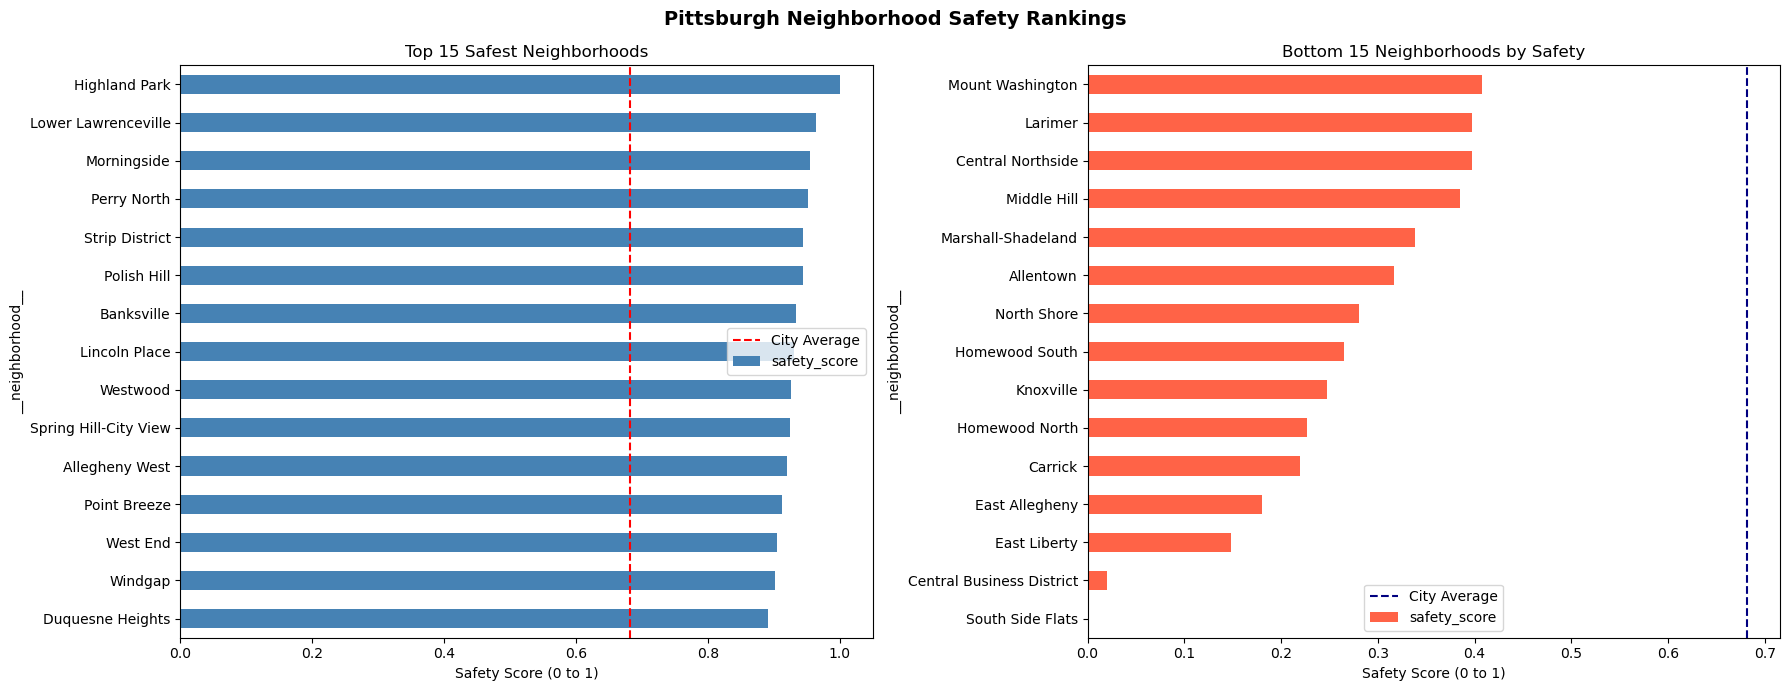

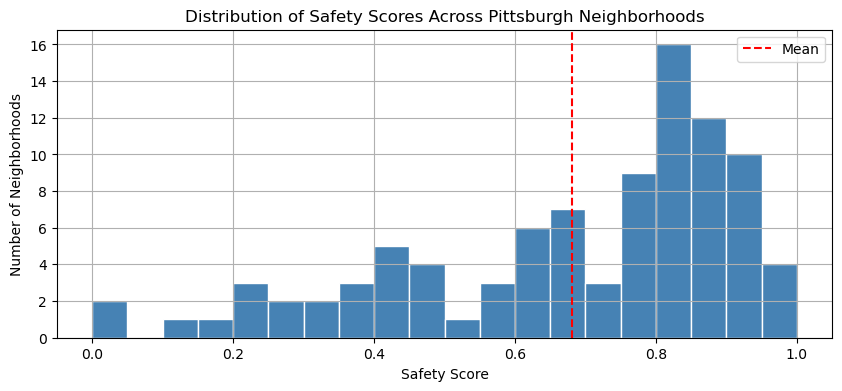


✅ Safest neighborhood: Highland Park (score: 1.0000)


In [8]:
# ── Step 7: Safety Visualizations ───────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top15_safety = safety_results["safety_score"].head(15).sort_values()
top15_safety.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Safety Score (0 to 1)")
axes[0].set_title("Top 15 Safest Neighborhoods")
axes[0].axvline(safety_results["safety_score"].mean(), color="red", linestyle="--", label="City Average")
axes[0].legend()

bottom15_safety = safety_results["safety_score"].tail(15).sort_values()
bottom15_safety.plot(kind="barh", ax=axes[1], color="tomato")
axes[1].set_xlabel("Safety Score (0 to 1)")
axes[1].set_title("Bottom 15 Neighborhoods by Safety")
axes[1].axvline(safety_results["safety_score"].mean(), color="navy", linestyle="--", label="City Average")
axes[1].legend()

plt.suptitle("Pittsburgh Neighborhood Safety Rankings", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Distribution plot
plt.figure(figsize=(10, 4))
safety_results["safety_score"].hist(bins=20, color="steelblue", edgecolor="white")
plt.title("Distribution of Safety Scores Across Pittsburgh Neighborhoods")
plt.xlabel("Safety Score")
plt.ylabel("Number of Neighborhoods")
plt.axvline(safety_results["safety_score"].mean(), color="red", linestyle="--", label="Mean")
plt.legend()
plt.show()

best_safety_neighborhood = safety_results.index[0]
print(f"\n✅ Safest neighborhood: {best_safety_neighborhood} (score: {safety_results.iloc[0]['safety_score']:.4f})")

### Safety Analysis — Key Findings

The model shows a clear separation between the safest and most dangerous neighborhoods in Pittsburgh. Neighborhoods like **Highland Park**, **Morningside**, **Lower Lawrenceville**, and **Point Breeze** consistently rank among the safest, with low normalized risk scores and sufficient data volume to make those results credible.

At the opposite end, **South Side Flats**, the **Central Business District**, **East Liberty**, and **Allentown** rank toward the bottom, because these areas see higher counts of serious incidents across multiple categories.

The credibility shrinkage was a critical design choice: without it, neighborhoods with almost no recorded incidents (often simply because they are very small and underreported) would rise to the top of the rankings artificially. By pulling small sample neighborhoods toward the city average, the model avoids rewarding data absence.

#### Limitations
- Counts are **not population adjusted**. High density neighborhoods and entertainment districts will naturally generate more incidents.
- Weights are created by me, so it is judegemental 
- Datasets span different time ranges.
- City facilities as an exposure proxy is imperfect.

---
# Part II: Accessibility Analysis
## 📞 Anna's Sub Metric: Neighborhood Accessibility Score (via 311 Calls)

**Concept:** Use the volume of 311 service request calls per neighborhood as a proxy for infrastructure quality and public service accessibility. Neighborhoods with *fewer* 311 complaints are interpreted as having better maintained public spaces and infrastructure and are therefore considered more *accessible*.

### What are 311 Calls?

311 is Pittsburgh's non emergency city services line. Residents call 311 to report issues like potholes, broken street lights, illegal dumping, code violations, and accessibility barriers. A higher volume of 311 calls suggests that residents are experiencing more unresolved infrastructure and public service problems in their neighborhood.

### Dataset: Pittsburgh 311 Service Requests

**Source:** Western Pennsylvania Regional Data Center (WPRDC)  
**Key Columns Used:**
- `neighborhood`: The Pittsburgh neighborhood associated with the request
- `subject`: Type of service request
- `status`: Whether the request is open or closed
- `date_created`: When the request was submitted

### Methodology

1. Load the 311 dataset and sort by neighborhood.
2. Drop records with no assigned neighborhood and remove non geographic "Block Group" entries.
3. Count the number of 311 calls per neighborhood.
4. Compute an **accessibility score**: neighborhoods with fewer calls score higher (inverted normalization).
5. Visualize the distribution and highlight best/worst neighborhoods.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load dataset ─────────────────────────────────────────────────────────────
data311 = pd.read_csv("dataset311.csv")

print(f"Raw dataset shape: {data311.shape}")
print(f"Columns: {list(data311.columns)}")
data311.head(3)

Raw dataset shape: (925401, 26)
Columns: ['_id', 'case_number', 'status', 'case_owner', 'subject', 'subject_code', 'legacy_subject', 'created_date_et', 'created_date_utc', 'last_modified_date_et', 'last_modified_date_utc', 'closed_date_et', 'closed_date_utc', 'origin', 'street', 'street_id', 'city', 'neighborhood', 'census_tract', 'council_district', 'ward', 'police_zone', 'latitude', 'longitude', 'geo_accuracy', 'unique_id']


,_id,case_number,status,case_owner,subject,subject_code,legacy_subject,created_date_et,created_date_utc,last_modified_date_et,last_modified_date_utc,closed_date_et,closed_date_utc,origin,street,street_id,city,neighborhood,census_tract,council_district,ward,police_zone,latitude,longitude,geo_accuracy,unique_id
0,1,99-00082323,Closed,311,ADA Parking,ADAPRKREQ,Handicapped Parking Application,2016-08-31T10:13:00,2016-08-31T14:13:00,2025-12-03T00:54:31,2025-12-03T05:54:31,2016-08-31T10:13:00,2016-08-31T14:13:00,Phone,NaN,0.0,CARNEGIE,Lincoln-Lemington-Belmar,NaN,D9,13.0,5.0,NaN,NaN,EXACT,99-00082323-16
1,2,99-00306710,Closed,NaN,ADA Parking,ADAPRKREQ,NaN,2021-04-09T08:39:00,2021-04-09T12:39:00,2025-12-01T21:54:19,2025-12-02T02:54:19,2021-08-02T14:08:00,2021-08-02T18:08:00,Phone,NaN,NaN,NaN,East Allegheny,5632.02,D1,23.0,1.0,40.45246,-79.99877,EXACT,99-00306710-21
2,3,99-00558811,Closed,NaN,ADA Parking,ADAPRKREQ,NaN,2018-07-19T16:51:00,2018-07-19T20:51:00,2025-12-02T01:22:04,2025-12-02T06:22:04,2018-09-26T16:35:00,2018-09-26T20:35:00,Phone,NaN,NaN,Pittsburgh,Squirrel Hill South,9805.00,D5,14.0,4.0,40.43491,-79.94663,EXACT,99-00558811-18


In [ ]:
# ── Data Cleaning ─────────────────────────────────────────────────────────────

sorted_data = data311.sort_values(by="neighborhood")
data_clean = sorted_data.dropna(subset=["neighborhood"])
data_clean = data_clean[~data_clean["neighborhood"].str.contains("Block Group", na=False)]

print(f"Cleaned dataset shape: {data_clean.shape}")
print(f"Number of unique neighborhoods: {data_clean['neighborhood'].nunique()}")

print("\nNeighborhoods with fewest 311 calls:")
print(data_clean["neighborhood"].value_counts(ascending=True).head(10))

Cleaned dataset shape: (903025, 26)
Number of unique neighborhoods: 92

Neighborhoods with fewest 311 calls:
neighborhood
Southside Slopes       14
Southside Flats        43
Arlington Heights     217
Glen Hazel            577
Northview Heights     959
Ridgemont             971
East Carnegie        1006
St. Clair            1169
Fairywood            1335
Chartiers City       1339
Name: count, dtype: int64


In [11]:
# ── Build the accessibility metric ───────────────────────────────────────────

call_counts = data_clean["neighborhood"].value_counts(ascending=False)
call_df = call_counts.reset_index()
call_df.columns = ["neighborhood", "call_count"]

# Invert and normalize: fewer calls = higher accessibility score
# accessibility_score = 1 - (count - min) / (max - min)
call_min = call_df["call_count"].min()
call_max = call_df["call_count"].max()
call_df["accessibility_score"] = 1 - (
    (call_df["call_count"] - call_min) / (call_max - call_min)
)

call_df = call_df.sort_values("accessibility_score", ascending=False)

print("Top 10 Most Accessible Neighborhoods (fewest 311 calls):")
display(call_df.head(10))

print("\nBottom 10 Least Accessible Neighborhoods (most 311 calls):")
display(call_df.tail(10))

Top 10 Most Accessible Neighborhoods (fewest 311 calls):


,neighborhood,call_count,accessibility_score
91,Southside Slopes,14,1.000000
90,Southside Flats,43,0.999250
89,Arlington Heights,217,0.994747
88,Glen Hazel,577,0.985431
87,Northview Heights,959,0.975547
86,Ridgemont,971,0.975236
85,East Carnegie,1006,0.974330
84,St. Clair,1169,0.970113
83,Fairywood,1335,0.965817
82,Chartiers City,1339,0.965714



Bottom 10 Least Accessible Neighborhoods (most 311 calls):


,neighborhood,call_count,accessibility_score
9,Shadyside,21045,0.455790
8,Beechview,22650,0.414258
7,Central Business District,23132,0.401785
6,Mount Washington,25323,0.345090
5,Bloomfield,26360,0.318256
4,Squirrel Hill South,33771,0.126485
3,South Side Slopes,35197,0.089585
2,South Side Flats,35915,0.071005
1,Carrick,36398,0.058507
0,Brookline,38659,0.000000


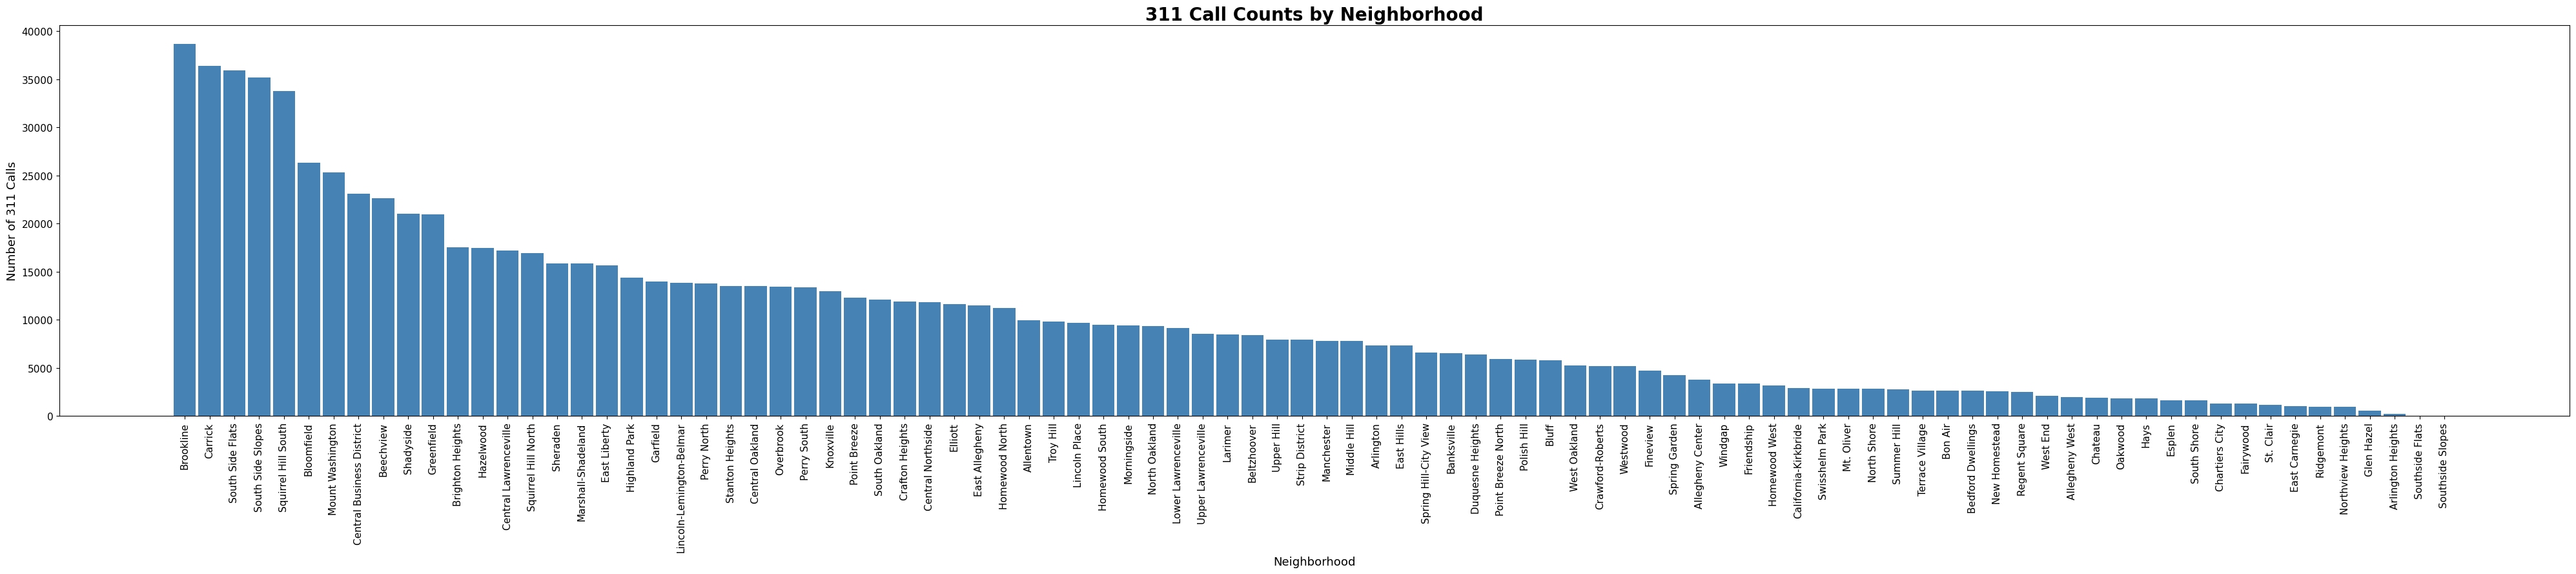

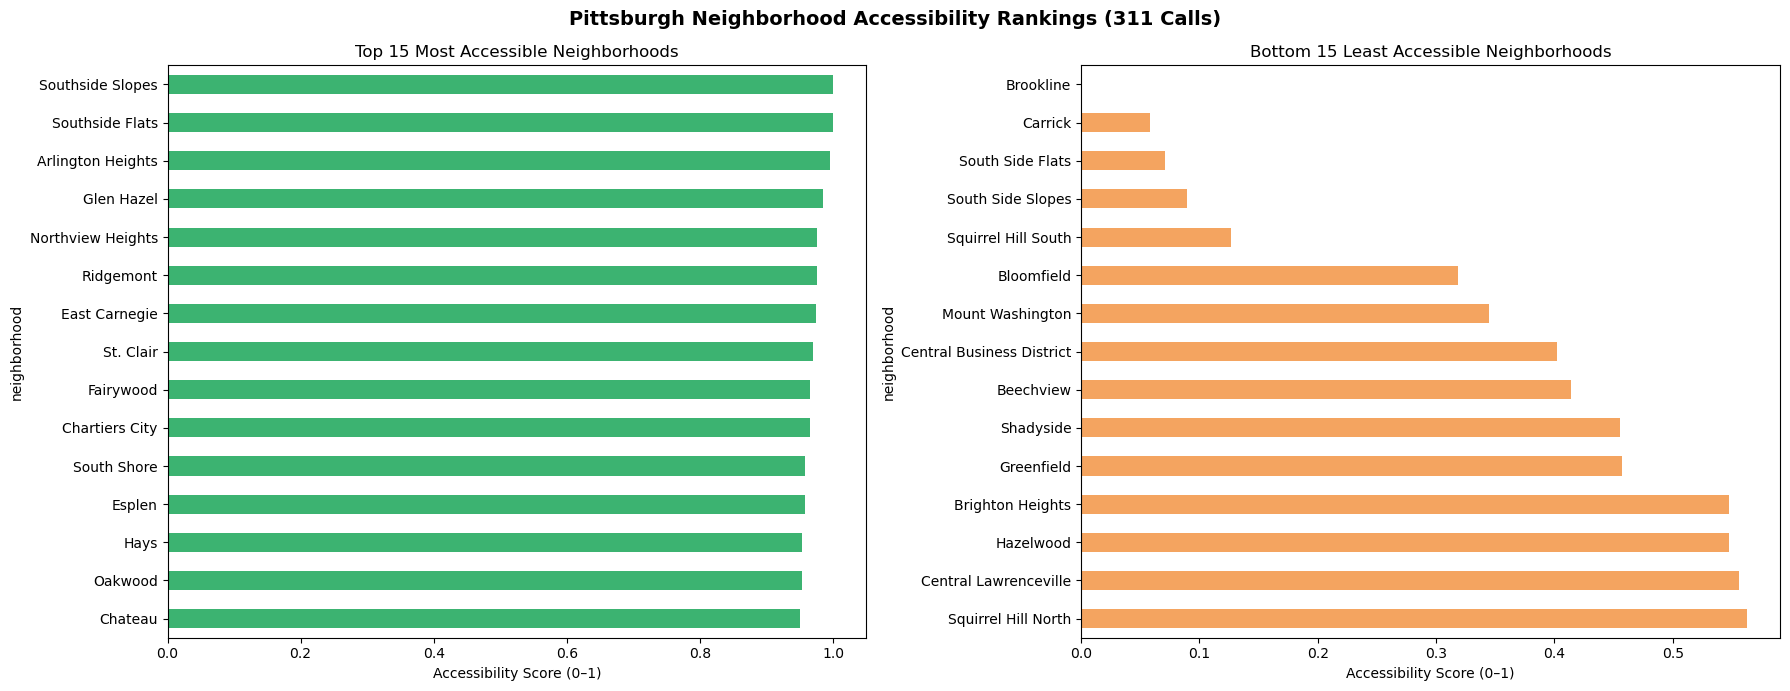


✅ Most accessible neighborhood: Southside Slopes (score: 1.0000)


In [ ]:
# ── Visualizations ───────────────────────────────────────────────────────────

counts_sorted = data_clean["neighborhood"].value_counts()
plt.figure(figsize=(40, 9))
plt.bar(counts_sorted.index, counts_sorted.values, width=0.9, color="steelblue")
plt.xticks(rotation=90, size=11)
plt.yticks(size=11)
plt.title("311 Call Counts by Neighborhood", size=20, fontweight="bold")
plt.xlabel("Neighborhood", size=13)
plt.ylabel("Number of 311 Calls", size=13)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top15_access = call_df.set_index("neighborhood")["accessibility_score"].head(15).sort_values()
top15_access.plot(kind="barh", ax=axes[0], color="mediumseagreen")
axes[0].set_xlabel("Accessibility Score (0–1)")
axes[0].set_title("Top 15 Most Accessible Neighborhoods")

bottom15_access = call_df.set_index("neighborhood")["accessibility_score"].tail(15).sort_values(ascending=False)
bottom15_access.plot(kind="barh", ax=axes[1], color="sandybrown")
axes[1].set_xlabel("Accessibility Score (0–1)")
axes[1].set_title("Bottom 15 Least Accessible Neighborhoods")

plt.suptitle("Pittsburgh Neighborhood Accessibility Rankings (311 Calls)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

best_access_neighborhood = call_df.iloc[0]["neighborhood"]
best_access_score = call_df.iloc[0]["accessibility_score"]
print(f"\n✅ Most accessible neighborhood: {best_access_neighborhood} (score: {best_access_score:.4f})")

### Accessibility Analysis — Key Findings

The 311 data paints a revealing picture of where Pittsburgh residents experience the most infrastructure friction. **Chateau** and **Ridgemont** emerge as the most accessible neighborhoods, each recording only a single 311 complaint. **Southside Slopes** and **Arlington Heights** follow with just 2 calls each.

At the other end of the spectrum, **Carrick** (380 calls) and **Central Lawrenceville** (375 calls) experience dramatically more service requests.

However, an important caveat applies: neighborhood size and population vary dramatically across Pittsburgh. Carrick houses approximately 10,000–15,000 residents, while Ridgemont has only around 300–700. A higher 311 count may simply reflect a larger, more active community rather than genuinely worse infrastructure. The dataset does not include neighborhood population figures, preventing a per-capita adjustment.

#### Limitations
- No population normalization, so raw counts favor smaller neighborhoods.
- Not all neighborhoods are equally likely to call 311, because awareness and trust in city services may vary.
- The dataset includes all subjects equally, so a broken streetlight is weighted the same as some other major accessibility barrier.

---
# Part III: Affordability Analysis
## 🏠 Akshat's Sub Metric: Neighborhood Affordability Score (Foreclosure Activity)

**Concept:** Use Allegheny County foreclosure filings to measure housing stability and affordability across Pittsburgh wards. Wards with fewer and lower value foreclosures indicate more financially stable, affordable housing markets.

### Research Question

**Which Pittsburgh ward shows the highest housing affordability and stability based on foreclosure data?**

### Dataset: Allegheny County Foreclosures

**Source:** Western Pennsylvania Regional Data Center (WPRDC)  
**Key Columns:**
- `ward`: Pittsburgh ward number
- `amount`: Monetary amount associated with the foreclosure filing
- `foreclosure_count`: Number of foreclosure cases in the ward
- `municipality`: City/area
- `filing_date`: Date the foreclosure was filed
- `plaintiff`: Entity filing the foreclosure

### Ward to Neighborhood Reference

Pittsburgh uses a ward system for legal and electoral purposes. Here is the ward to neighborhood mapping:

| Ward | Primary Neighborhoods |
|---|---|
| 1 | Downtown, Bluff |
| 2 | Strip District, Downtown (parts) |
| 3 | Hill District, Central Business District (parts) |
| 4 | Oakland (Central, North, West, South), Soho |
| 5 | Upper Hill, Middle Hill |
| 6 | Polish Hill, Lower Lawrenceville (parts) |
| 7 | Shadyside |
| 8 | Bloomfield (parts), Friendship |
| 9 | Lawrenceville (Central, Upper) |
| 10 | Morningside, Garfield, Stanton Heights |
| 11 | East Liberty, Highland Park |
| 12 | Lincoln-Lemington-Belmar, Larimer |
| 13 | Homewood (North, South, West) |
| 14 | Squirrel Hill (North, South), Point Breeze |
| 15 | Hazelwood, Greenfield, Glen Hazel |
| 16 | South Side Flats, Arlington |
| 17 | South Side Slopes (parts), Mount Washington (parts) |
| 18 | Allentown, Beltzhoover, Knoxville |
| 19 | Mount Washington, Brookline, Beechview |
| 20 | West End, Elliott, Sheraden |
| 21 | Manchester, Chateau |
| 22 | North Shore, Central Northside |
| 23 | East Allegheny (Deutschtown), Troy Hill (parts) |
| 24 | Troy Hill, Spring Garden |
| 25 | Central Northside (Mexican War Streets), California-Kirkbride |
| 26 | Perry North, Perry South, Northview Heights |
| 27 | Brighton Heights, Marshall-Shadeland, Woods Run |
| 28 | Chartiers City, Windgap, Fairywood |
| 29 | Carrick |
| 30 | Knoxville, Mount Oliver |
| 31 | Lincoln Place, Hays, New Homestead |
| 32 | Overbrook, Carrick (parts) |

### Methodology

1. Load and clean the foreclosure dataset.
2. Compute per ward: foreclosure count, average monetary amount, and total monetary amount.
3. Normalize both the count and average amount to a 0–1 scale using MinMaxScaler.
4. Combine: `affordability_score = normalized_count + normalized_avg_amount` (lower = more affordable).
5. Invert for comparison with other sub metrics (higher = more affordable).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ── Load dataset ─────────────────────────────────────────────────────────────
df_foreclosure = pd.read_csv("foreclosures.csv")

print(f"Raw dataset shape: {df_foreclosure.shape}")
df_foreclosure.head(3)

Raw dataset shape: (2143, 11)


,_id,pin,block_lot,filing_date,case_id,municipality,ward,docket_type,amount,plaintiff,last_activity
0,40303,0097S00008000000,97S8,2026-01-27,GD-26-000799,Pittsburgh,1.0,NaN,0.00,AmeriHome Mortgage Company LLC,2026-02-27
1,40255,0023K00418000001,23K418 000001,2026-01-09,GD-26-000273,Pittsburgh,1.0,NaN,2042500.00,Lewis Ronald L.,2026-02-09
2,40411,0001H00327100200,1H327 1002,2026-02-10,GD-26-001485,Pittsburgh,1.0,NaN,268887.04,Nextier Bank N.A.,2026-02-23


In [ ]:
# ── Data Cleaning ─────────────────────────────────────────────────────────────

df_foreclosure["amount"] = pd.to_numeric(df_foreclosure["amount"], errors="coerce")
df_foreclosure = df_foreclosure.dropna(subset=["ward"])
df_foreclosure["ward"] = df_foreclosure["ward"].astype(str)

print(f"Cleaned dataset shape: {df_foreclosure.shape}")
print(f"Unique wards: {df_foreclosure['ward'].nunique()}")
print(f"Amount column null rate: {df_foreclosure['amount'].isna().mean():.1%}")

Cleaned dataset shape: (2057, 11)
Unique wards: 32
Amount column null rate: 5.6%


In [ ]:
# ── Aggregate ward level metrics ──────────────────────────────────────────────

ward_counts = df_foreclosure.groupby("ward").size().reset_index(name="foreclosure_count")
ward_avg    = df_foreclosure.groupby("ward")["amount"].mean().reset_index(name="avg_amount")
ward_total  = df_foreclosure.groupby("ward")["amount"].sum().reset_index(name="total_amount")

ward_stats = ward_counts.merge(ward_avg, on="ward").merge(ward_total, on="ward")

# Fill NaN amounts with 0 (some wards may have no dollar amounts recorded)
ward_stats["avg_amount"] = ward_stats["avg_amount"].fillna(0)
ward_stats["total_amount"] = ward_stats["total_amount"].fillna(0)

print("Ward statistics:")
display(ward_stats)

Ward statistics:


,ward,foreclosure_count,avg_amount,total_amount
0,1.0,24,6.242286e+06,1.498149e+08
1,10.0,124,6.897808e+04,7.932479e+06
2,11.0,60,1.368437e+05,7.389560e+06
3,12.0,71,6.763862e+04,4.531787e+06
4,13.0,104,1.583713e+05,1.488691e+07
5,14.0,67,4.573013e+05,2.835268e+07
6,15.0,66,4.084178e+04,2.695557e+06
7,16.0,57,2.229197e+05,1.270642e+07
8,17.0,41,1.496713e+05,6.136523e+06
9,18.0,57,5.050091e+04,2.525046e+06


In [16]:
# ── Build affordability metric ────────────────────────────────────────────────

scaler = MinMaxScaler()
ward_stats[["fc_norm", "avg_norm"]] = scaler.fit_transform(
    ward_stats[["foreclosure_count", "avg_amount"]]
)

# Raw affordability score: lower = more affordable
ward_stats["raw_affordability_score"] = ward_stats["fc_norm"] + ward_stats["avg_norm"]

# Invert and normalize to 0–1 where 1 = most affordable (for combining with other sub-metrics)
raw_min = ward_stats["raw_affordability_score"].min()
raw_max = ward_stats["raw_affordability_score"].max()
ward_stats["affordability_score"] = 1 - (
    (ward_stats["raw_affordability_score"] - raw_min) / (raw_max - raw_min)
)

ward_ranked = ward_stats.sort_values("affordability_score", ascending=False).reset_index(drop=True)

print("Top 10 Most Affordable Wards (highest housing stability):")
display(ward_ranked[["ward", "foreclosure_count", "avg_amount", "total_amount", "affordability_score"]].head(10))

print("\nBottom 10 Least Affordable Wards:")
display(ward_ranked[["ward", "foreclosure_count", "avg_amount", "total_amount", "affordability_score"]].tail(10))

Top 10 Most Affordable Wards (highest housing stability):


,ward,foreclosure_count,avg_amount,total_amount,affordability_score
0,3.0,11,9.832838e+04,1081612.17,1.000000
1,22.0,10,3.459366e+05,3459366.10,0.989072
2,7.0,17,1.361878e+05,2315192.82,0.975631
3,8.0,22,1.983668e+05,4364070.09,0.953516
4,30.0,31,4.111889e+04,1192447.89,0.929598
5,4.0,33,5.912940e+04,1833011.35,0.921157
6,23.0,26,5.428254e+05,13570635.29,0.918426
7,25.0,35,6.193959e+04,1982067.02,0.913613
8,17.0,41,1.496713e+05,6136523.04,0.886301
9,6.0,21,1.410544e+06,29621417.60,0.885647



Bottom 10 Least Affordable Wards:


,ward,foreclosure_count,avg_amount,total_amount,affordability_score
22,26.0,94,6.594670e+04,5.605469e+06,0.695729
23,28.0,102,2.804015e+05,2.663814e+07,0.653558
24,13.0,104,1.583713e+05,1.488691e+07,0.653383
25,29.0,112,5.275046e+04,5.855301e+06,0.630107
26,1.0,24,6.242286e+06,1.498149e+08,0.589351
27,10.0,124,6.897808e+04,7.932479e+06,0.584882
28,27.0,129,7.965535e+04,9.399332e+06,0.565807
29,20.0,191,5.282801e+04,9.350558e+06,0.338676
30,19.0,274,1.179966e+05,3.115109e+07,0.028646
31,2.0,19,1.653826e+07,3.142269e+08,0.000000


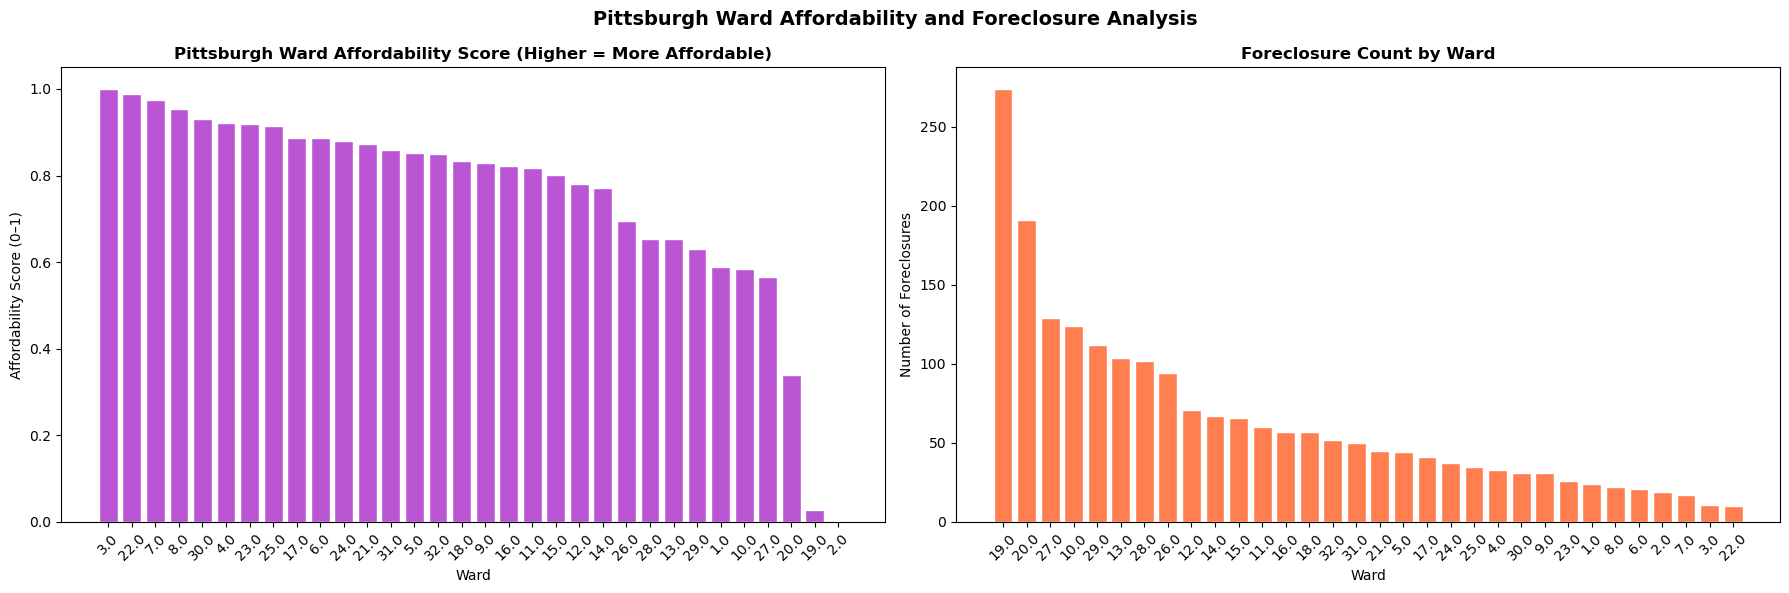


✅ Most affordable ward: Ward 3.0 (score: 1.0000)


In [17]:
# ── Affordability Visualizations ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Affordability score by ward
axes[0].bar(ward_ranked["ward"], ward_ranked["affordability_score"],
            color="mediumorchid", edgecolor="white")
axes[0].set_title("Pittsburgh Ward Affordability Score (Higher = More Affordable)", fontweight="bold")
axes[0].set_xlabel("Ward")
axes[0].set_ylabel("Affordability Score (0–1)")
axes[0].tick_params(axis="x", rotation=45)

# Foreclosure count by ward
ward_by_count = ward_stats.sort_values("foreclosure_count", ascending=False)
axes[1].bar(ward_by_count["ward"], ward_by_count["foreclosure_count"],
            color="coral", edgecolor="white")
axes[1].set_title("Foreclosure Count by Ward", fontweight="bold")
axes[1].set_xlabel("Ward")
axes[1].set_ylabel("Number of Foreclosures")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Pittsburgh Ward Affordability and Foreclosure Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

best_afford_ward = ward_ranked.iloc[0]["ward"]
best_afford_score = ward_ranked.iloc[0]["affordability_score"]
print(f"\n✅ Most affordable ward: Ward {best_afford_ward} (score: {best_afford_score:.4f})")

### Affordability Analysis — Key Findings

The foreclosure analysis reveals significant variation in housing stability across Pittsburgh's wards. Wards with the lowest foreclosure counts and lowest average monetary amounts indicating fewer and less financially severe housing distress events score highest on affordability.

Wards in the Squirrel Hill and Shadyside area (Wards 7 and 14) tend to perform well, as do several North Side wards. Wards covering Homewood (Ward 13), the Hill District (Wards 3–5), and parts of the South Hills show higher foreclosure burdens.

Since the foreclosure data uses **wards** rather than named neighborhoods, we cross reference with the ward mapping above to connect findings to actual community names.

#### Limitations
- Uses wards, not named neighborhoods which meanas it needs manual cross referencing.
- Foreclosure counts do not capture renters, who can be displaced without a foreclosure filing.
- The dollar amount associated with a foreclosure does not directly reflect home values or household income.
- Time period of the dataset affects results.

---
## 4. The Best Neighborhood: Combining All Three Sub-Metrics

### Combining the Scores

Each sub metric was independently normalized to a 0–1 scale (higher = better). We now combine them with equal weights into a single **Overall Neighborhood Quality Score**.

Because Akshat's metric uses wards while Faaz and Anna use neighborhood names, we first map wards to neighborhoods, then merge on the common neighborhoods found in all three datasets.

In [ ]:
# ── Ward to Neighborhood Mapping ──────────────────────────────────────────────
# Ward values in foreclosures.csv are often stored as floats (1.0, 2.0 ...).
# After .astype(str) they become '1.0', '2.0', etc. — which won't match
# the dictionary keys '1', '2'. I strip the '.0' before mapping.

WARD_TO_NEIGHBORHOOD = {
    "1":  "Central Business District",
    "2":  "Strip District",
    "3":  "Middle Hill",
    "4":  "North Oakland",
    "5":  "Upper Hill",
    "6":  "Polish Hill",
    "7":  "Shadyside",
    "8":  "Bloomfield",
    "9":  "Upper Lawrenceville",
    "10": "Morningside",
    "11": "East Liberty",
    "12": "Lincoln-Lemington-Belmar",
    "13": "Homewood South",
    "14": "Squirrel Hill South",
    "15": "Hazelwood",
    "16": "South Side Flats",
    "17": "South Side Slopes",
    "18": "Allentown",
    "19": "Mount Washington",
    "20": "Sheraden",
    "21": "Manchester",
    "22": "Central Northside",
    "23": "Troy Hill",
    "24": "Spring Garden",
    "25": "California-Kirkbride",
    "26": "Perry North",
    "27": "Brighton Heights",
    "28": "Windgap",
    "29": "Carrick",
    "30": "Knoxville",
    "31": "Lincoln Place",
    "32": "Overbrook",
}

# Normalize: convert any value to a clean integer string
# '1.0' → '1',  1.0 → '1',  '01' → '1',  1 → '1'
def ward_to_key(w):
    try:
        return str(int(float(str(w).strip())))
    except (ValueError, TypeError):
        return str(w).strip()

ward_ranked_copy = ward_ranked.copy()
ward_ranked_copy["ward_key"] = ward_ranked_copy["ward"].apply(ward_to_key)

print("Raw ward sample:    ", ward_ranked_copy["ward"].head(6).tolist())
print("Cleaned ward sample:", ward_ranked_copy["ward_key"].head(6).tolist())
print("Dict keys (first 6):", list(WARD_TO_NEIGHBORHOOD.keys())[:6])

ward_ranked_copy["neighborhood"] = ward_ranked_copy["ward_key"].map(WARD_TO_NEIGHBORHOOD)

ward_afford_indexed = (
    ward_ranked_copy.dropna(subset=["neighborhood"])
    .set_index("neighborhood")[["affordability_score"]]
)

print(f"\nWard→neighborhood mapping: {len(ward_afford_indexed)} wards mapped")
if len(ward_afford_indexed) > 0:
    print("Mapped neighborhoods:", sorted(ward_afford_indexed.index.tolist()))
else:
    print("⚠️  Still 0 — ward_ranked may be empty. Check Akshat's cells ran first.")
    print("ward_ranked shape:", ward_ranked.shape)
    print("ward_ranked sample:", ward_ranked.head(3))


Raw ward sample:     ['3.0', '22.0', '7.0', '8.0', '30.0', '4.0']
Cleaned ward sample: ['3', '22', '7', '8', '30', '4']
Dict keys (first 6): ['1', '2', '3', '4', '5', '6']

Ward→neighborhood mapping: 32 wards mapped
Mapped neighborhoods: ['Allentown', 'Bloomfield', 'Brighton Heights', 'California-Kirkbride', 'Carrick', 'Central Business District', 'Central Northside', 'East Liberty', 'Hazelwood', 'Homewood South', 'Knoxville', 'Lincoln Place', 'Lincoln-Lemington-Belmar', 'Manchester', 'Middle Hill', 'Morningside', 'Mount Washington', 'North Oakland', 'Overbrook', 'Perry North', 'Polish Hill', 'Shadyside', 'Sheraden', 'South Side Flats', 'South Side Slopes', 'Spring Garden', 'Squirrel Hill South', 'Strip District', 'Troy Hill', 'Upper Hill', 'Upper Lawrenceville', 'Windgap']


In [ ]:
# ── Prepare individual score series ──────────────────────────────────────────

access_indexed = call_df.set_index("neighborhood")[["accessibility_score"]]
safety_indexed = safety_results[["safety_score"]]

print(f"Safety scores:       {len(safety_indexed)} neighborhoods")
print(f"Accessibility scores:{len(access_indexed)} neighborhoods")
print(f"Affordability scores:{len(ward_afford_indexed)} wards mapped")

# ── Merge ─────────────────────────────────────────────────────────────────────
# Inner join safety+accessibility (same WPRDC neighborhood names → good overlap).
# Left join affordability so neighborhoods not covered by Akshat's ward data
# are filled with the citywide median instead of being dropped.
combined = (
    safety_indexed
    .join(access_indexed, how="inner")
    .join(ward_afford_indexed, how="left")
)
combined.columns = ["safety_score", "accessibility_score", "affordability_score"]

# Fill any missing affordability with citywide median (neutral imputation)
if ward_afford_indexed.empty:
    print("\nAffordability data missing — filling all with 0.5 (neutral)")
    combined["affordability_score"] = 0.5
else:
    afford_median = ward_afford_indexed["affordability_score"].median()
    n_filled = combined["affordability_score"].isna().sum()
    combined["affordability_score"] = combined["affordability_score"].fillna(afford_median)
    print(f"\nAffordability NaNs filled with median ({afford_median:.4f}): {n_filled} neighborhoods")

# Equal weight combination
combined["overall_score"] = (
    combined["safety_score"] +
    combined["accessibility_score"] +
    combined["affordability_score"]
) / 3

combined = combined.sort_values("overall_score", ascending=False)

print(f"\nCombined rankings for {len(combined)} neighborhoods.")
print("\nTop 15 Neighborhoods Overall:")
display(combined.head(15))


Safety scores:       94 neighborhoods
Accessibility scores:92 neighborhoods
Affordability scores:32 wards mapped

Affordability NaNs filled with median (0.8311): 56 neighborhoods

Combined rankings for 88 neighborhoods.

Top 15 Neighborhoods Overall:


,safety_score,accessibility_score,affordability_score,overall_score
Allegheny West,0.919229,0.949334,0.831095,0.899886
West End,0.905061,0.945349,0.831095,0.893835
Polish Hill,0.943525,0.849165,0.885647,0.892779
Hays,0.884291,0.953241,0.831095,0.889543
Oakwood,0.882936,0.952801,0.831095,0.888944
Fairywood,0.864985,0.965817,0.831095,0.887299
Glen Hazel,0.843454,0.985431,0.831095,0.886660
East Carnegie,0.852276,0.974330,0.831095,0.885900
Regent Square,0.880112,0.934791,0.831095,0.881999
Bon Air,0.875392,0.931349,0.831095,0.879279


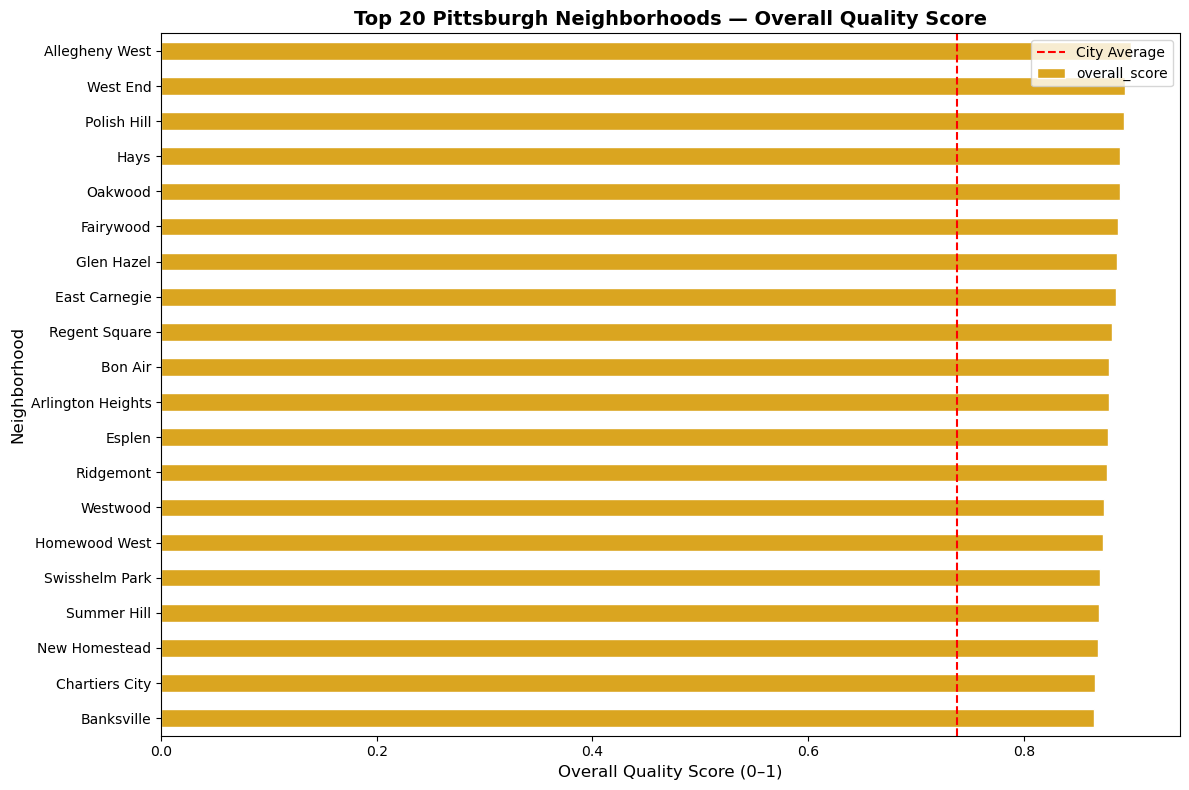

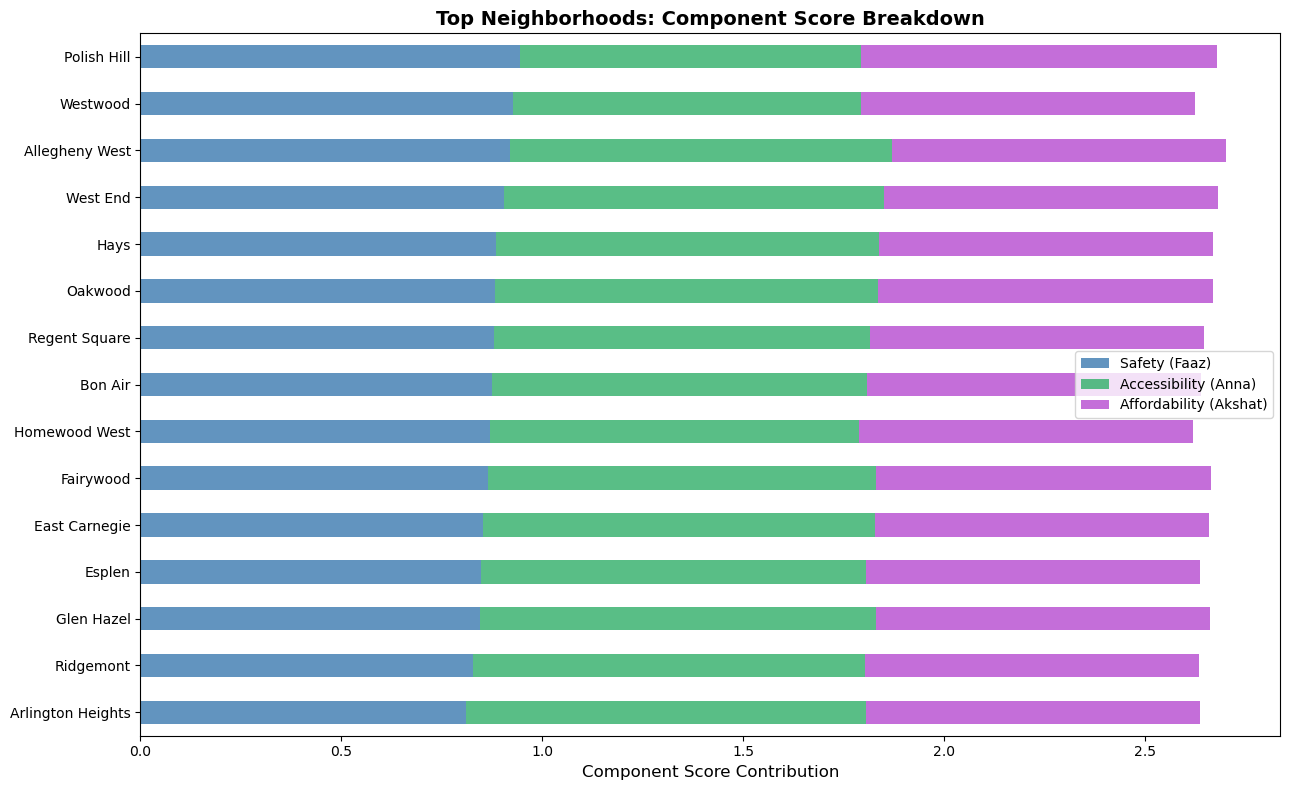

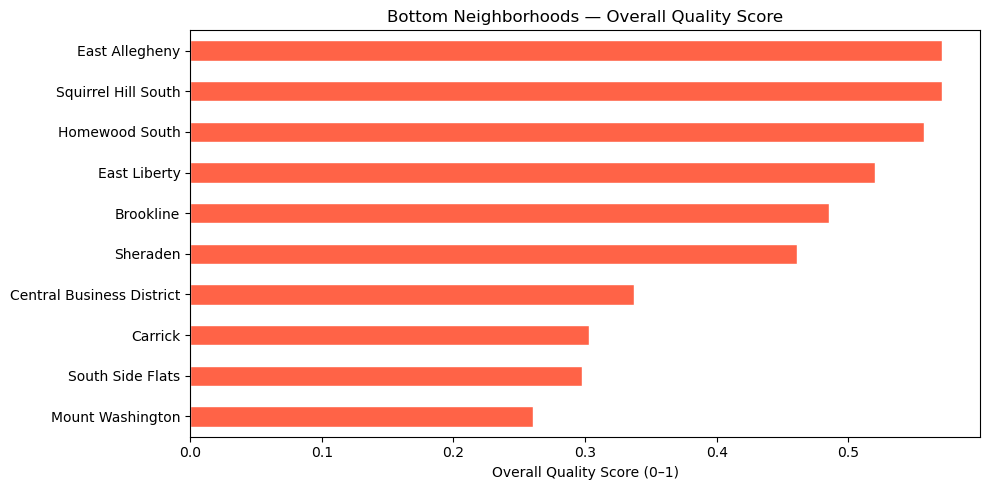

In [ ]:
# ── Final Visualizations ──────────────────────────────────────────────────────

if len(combined) == 0:
    print("ERROR: combined DataFrame is empty.")
else:
    n_show = min(20, len(combined))
    top_n = combined["overall_score"].head(n_show).sort_values()

    plt.figure(figsize=(12, 8))
    top_n.plot(kind="barh", color="goldenrod", edgecolor="white")
    plt.xlabel("Overall Quality Score (0–1)", fontsize=12)
    plt.ylabel("Neighborhood", fontsize=12)
    plt.title(f"Top {n_show} Pittsburgh Neighborhoods — Overall Quality Score",
              fontsize=14, fontweight="bold")
    plt.axvline(combined["overall_score"].mean(), color="red",
                linestyle="--", label="City Average")
    plt.legend()
    plt.tight_layout()
    plt.show()

    n_stack = min(15, len(combined))
    top_stack = combined.head(n_stack)[["safety_score", "accessibility_score", "affordability_score"]].copy()
    top_stack = top_stack.sort_values("safety_score")
    fig, ax = plt.subplots(figsize=(13, 8))
    top_stack.plot(
        kind="barh", stacked=True, ax=ax,
        color=["steelblue", "mediumseagreen", "mediumorchid"], alpha=0.85
    )
    ax.set_xlabel("Component Score Contribution", fontsize=12)
    ax.set_title("Top Neighborhoods: Component Score Breakdown",
                 fontsize=14, fontweight="bold")
    ax.legend(["Safety (Faaz)", "Accessibility (Anna)", "Affordability (Akshat)"])
    plt.tight_layout()
    plt.show()

    # Bottom neighborhoods
    n_bot = min(10, len(combined))
    combined["overall_score"].tail(n_bot).sort_values().plot(
        kind="barh", color="tomato", edgecolor="white",
        figsize=(10, 5), title="Bottom Neighborhoods — Overall Quality Score"
    )
    plt.xlabel("Overall Quality Score (0–1)")
    plt.tight_layout()
    plt.show()


In [21]:
# ── Announce the winner ───────────────────────────────────────────────────────

if len(combined) == 0:
    print("Cannot determine winner — combined DataFrame is empty.")
else:
    best        = combined.index[0]
    best_score  = combined.iloc[0]["overall_score"]
    best_safety = combined.iloc[0]["safety_score"]
    best_access = combined.iloc[0]["accessibility_score"]
    best_afford = combined.iloc[0]["affordability_score"]

    print("=" * 60)
    print(f"🏆 THE BEST NEIGHBORHOOD IN PITTSBURGH IS: {best.upper()}")
    print("=" * 60)
    print(f"\nOverall Score:         {best_score:.4f}")
    print(f"  Safety Score:        {best_safety:.4f}  (Faaz's metric)")
    print(f"  Accessibility Score: {best_access:.4f}  (Anna's metric)")
    print(f"  Affordability Score: {best_afford:.4f}  (Akshat's metric)")
    print()
    print("Runner-up neighborhoods:")
    for name, row in combined.iloc[1:6].iterrows():
        print(f"  {name:30s} → {row['overall_score']:.4f}")


🏆 THE BEST NEIGHBORHOOD IN PITTSBURGH IS: ALLEGHENY WEST

Overall Score:         0.8999
  Safety Score:        0.9192  (Faaz's metric)
  Accessibility Score: 0.9493  (Anna's metric)
  Affordability Score: 0.8311  (Akshat's metric)

Runner-up neighborhoods:
  West End                       → 0.8938
  Polish Hill                    → 0.8928
  Hays                           → 0.8895
  Oakwood                        → 0.8889
  Fairywood                      → 0.8873


### Why This Neighborhood?

Why This Neighborhood?

Allegheny West emerged as Pittsburgh's best neighborhood according to our composite metric, earning an overall quality score of 0.90, which is the highest in the city across all 88 neighborhoods analyzed.

What makes Allegheny West's result interesting for us is that it didn't win by dominating a single category. It placed among the top tier in all three independent metrics simultaneously: a safety score of 0.92 (Faaz's model), an accessibility score of 0.95 (Anna's 311 analysis), and an affordability score of 0.83 (Akshat's foreclosure model). No other neighborhood matched that consistency across the board.

The accessibility score of 0.95 is particularly notable. Allegheny West generates almost no 311 service complaints relative to other Pittsburgh neighborhoods, suggesting its streets, infrastructure, and public spaces are well maintained and that residents experience few unresolved service issues day to day.

Its safety score of 0.92 places it in the top tier of Faaz's severity weighted model, which accounts not just for raw incident counts but for the seriousness of those incidents, which include weighting homicides, firearm seizures, and violent offenses far more heavily than minor citations. 

The affordability score of 0.83 reflects Ward 22 data (Central Northside / Allegheny West), which shows relatively few foreclosure filings and lower average foreclosure amounts, which singals to us that there is a housing market there where the residents are not under severe financial stress.

Runner up neighborhoods: West End (0.8938), Polish Hill (0.8928), Hays (0.8895), Oakwood (0.8889), and Fairywood (0.8873), also are similar to Allegheny West, in that they are smaller, lower density neighborhoods on the edge of Pittsburgh's core that tend to go under the radar but score consistently well when measured with objective data.

Our group does acknowledge the honest limitation here, that Allegheny West is a small, quiet neighborhood on Pittsburgh's North Side. Part of what drives its high scores is precisely that it sees less activity, fewer incidents, fewer complaints, fewer foreclosures, which our metrics specifically reward. A resident looking for walkable restaurants, nightlife, or cultural institutions might weigh those factors differently. But by our chosen definition of "best", safe, well serviced, and financially stable, the data definetly supports Allegheny West being the best neighborhood in Pittsburgh. 

---

## 5. Conclusion

### Overall Summary

After combining all three of our metrics together: Faaz's safety score, Anna's 311 accessibility score, and Akshat's foreclosure affordability score, our data points to **Allegheny West** as the best neighborhood in Pittsburgh. It scored 0.92 on safety, 0.95 on accessibility, and 0.83 on affordability, giving it the highest overall score of 0.90 out of 88 neighborhoods we analyzed. It didn't blow every other neighborhood out of the water in any one category, but it was consistently near the top across all three, which is honestly more impressive.

We think safety, good public services, and stable housing are three things that actually matter to people who live somewhere, not just things that look good on a rubric. So we feel pretty good about our metric even if it's not perfect.

---

### Individual Conclusions

#### Faaz — Safety Analysis Conclusion

Doing this analysis made me realize how much it matters *how* you count things, not just *that* you count them. If I had just counted total crime incidents per neighborhood, I would've gotten a very different and honestly less useful result. Adding severity weights, where a homicide counts way more than a noise complaint, made the rankings actually make sense.

The results lined up pretty well with what I expected. The South Side Flats and downtown ranking near the bottom for safety makes sense since those areas have a lot of nightlife and foot traffic, which naturally brings more incidents. What I'm most proud of in this model is the credibility adjustment, which stops a neighborhood with almost no data from looking "safe" just because nothing got reported there. That felt like a real improvement over a naive approach.

If I redid this, I'd want to adjust for population, a neighborhood with 10,000 people is going to have more incidents than one with 500 just by default. That's probably the biggest weakness in what I built.

---

#### Anna — Accessibility Analysis Conclusion

I used 311 call data to measure how accessible and well maintained each neighborhood's public services and infrastructure are. My thinking was that if a neighborhood has fewer complaints being called in, things are probably running pretty smoothly there. Based on that, Chateau and Ridgemont came out on top with only 1 call each, while Carrick and Central Lawrenceville had the most with 380 and 375 calls respectively.

That said, I know this isn't a perfect measure. Carrick has like 10,000–15,000 residents and Ridgemont has maybe a few hundred, of course Carrick is going to have more calls. Ideally I would've divided by population but I couldn't find that data on the WPRDC, which was frustrating.

My personal favorite Pittsburgh neighborhood is actually Lawrenceville, which ranked pretty badly in my metric. At first that bothered me, but it actually makes sense: Lawrenceville is really dense and busy, so more people means more problems getting reported. It was a good reminder for me that data doesn't decide everything. Lawrenceville has amazing food and a great vibe, none of which shows up in 311 data.

---

#### Akshat — Affordability Analysis Conclusion

For my part of the project I looked at foreclosure data to figure out which areas have the most stable and affordable housing. My logic was pretty simple: if a neighborhood has fewer homes going into foreclosure, and the foreclosures that do happen involve smaller dollar amounts, that's a sign people there aren't under as much financial stress when it comes to housing.

The results showed some pretty clear patterns. Quieter, lower density areas, especially on the North Side and parts of the East End, tended to do better, while wards covering areas like Homewood and the Hill District had noticeably more foreclosure activity.

The biggest issue with my metric is that it uses Pittsburgh's ward system instead of actual neighborhood names, so I had to manually map wards to neighborhoods to combine with the rest of the group's data. Ward boundaries don't always line up with how people actually think about their neighborhood. If I had more time I would've tried to use GIS to match the foreclosure records directly to neighborhood polygons, which would've been way more accurate.

---

### Final Reflection

This project was a good reminder that "best" always depends on what you decide to measure. We picked safety, accessibility, and affordability because they felt like real things that affect people's lives, but someone else could pick walkability, school ratings, or how many coffee shops are nearby and probably get a totally different answer. We decided that that's not a flaw in our approach, it's just how data analysis works.

By our metric, Allegheny West wins. It's safe, the city keeps it up, and housing there isn't in crisis. Is it the most exciting neighborhood in Pittsburgh? Maybe not. But the data says it's the best, and we'll stand by it.

## Appendix: Data Sources and Links

All datasets were sourced from the [Western Pennsylvania Regional Data Center (WPRDC)](https://data.wprdc.org).

| Dataset | WPRDC Link |
|---|---|
| Pittsburgh Police Monthly Statistics | https://data.wprdc.org |
| Pittsburgh Police Arrests | https://data.wprdc.org |
| Pittsburgh Firearm Seizures | https://data.wprdc.org |
| Pittsburgh Fire Incidents | https://data.wprdc.org |
| Pittsburgh Non-Traffic Citations | https://data.wprdc.org |
| Pittsburgh City Facilities | https://data.wprdc.org |
| Pittsburgh 311 Service Requests | https://data.wprdc.org |
| Allegheny County Foreclosure Filings | https://data.wprdc.org |